In [10]:
#1. Sankey Diagram
import pandas as pd
import plotly.graph_objects as go

# Sample energy flow data (simplified)
data = pd.DataFrame({
    'source': ['Coal', 'Coal', 'Solar', 'Solar', 'Natural Gas', 'Natural Gas'],
    'target': ['Electricity', 'Industrial', 'Electricity', 'Residential', 'Electricity', 'Commercial'],
    'value': [80, 20, 30, 10, 60, 25]
})

# Create a label list and map to indices
labels = list(pd.unique(data[['source', 'target']].values.ravel('K')))
label_map = {label: idx for idx, label in enumerate(labels)}

# Map source/target to indices
data['source_idx'] = data['source'].map(label_map)
data['target_idx'] = data['target'].map(label_map)

# Create the Sankey figure
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        label=labels,
        color="lightblue"
    ),
    link=dict(
        source=data['source_idx'],
        target=data['target_idx'],
        value=data['value'],
        color="rgba(0,100,200,0.4)"
    )
))

fig.update_layout(title_text="Energy Flow from Sources to Usage Sectors", font_size=12)
fig.show()


In [11]:
#2. Alluvial Plot
import pandas as pd
import plotly.express as px

# Sample synthetic data
df = pd.DataFrame({
    "Channel": ["Email", "Email", "Social", "Social", "Search", "Search"],
    "Category": ["Electronics", "Clothing", "Electronics", "Home", "Clothing", "Home"],
    "Outcome": ["Purchase", "No Purchase", "Purchase", "Purchase", "No Purchase", "Purchase"],
    "Count": [120, 80, 90, 60, 50, 110]
})

# Repeat rows based on count to simulate frequency (Plotly expects row-wise data)
df_expanded = df.loc[df.index.repeat(df["Count"])].reset_index(drop=True)

# Create Alluvial (Parallel Categories) plot
fig = px.parallel_categories(
    df_expanded,
    dimensions=["Channel", "Category", "Outcome"],
    color_continuous_scale=px.colors.sequential.Blues,
    labels={"Channel": "Marketing Channel", "Category": "Product", "Outcome": "Result"},
)

fig.update_layout(title="Customer Journey Flow: Channel → Category → Outcome")
fig.show()


In [12]:
#3. Chord Diagram (with Bokeh)
import pandas as pd
import numpy as np
import networkx as nx
from bokeh.io import output_notebook, show
from bokeh.plotting import from_networkx
from bokeh.models import Plot, Range1d, MultiLine, Circle, HoverTool
from bokeh.palettes import Category10

output_notebook()

# Sample communication flow table
data = pd.DataFrame({
    "source": ["HR", "HR", "IT", "IT", "Sales", "Sales", "Finance", "Finance"],
    "target": ["IT", "Finance", "Sales", "HR", "HR", "Finance", "Sales", "IT"],
    "value": [30, 10, 20, 15, 25, 35, 40, 5]
})

# Create directed weighted graph
G = nx.DiGraph()
for _, row in data.iterrows():
    G.add_edge(row['source'], row['target'], weight=row['value'])

# Compute circular layout
layout = nx.circular_layout(G)

# Create plot
plot = Plot(width=600, height=600, x_range=Range1d(-1.5, 1.5), y_range=Range1d(-1.5, 1.5))
plot.title.text = "Inter-Department Communication Flow"

# Create renderer
graph_renderer = from_networkx(G, layout, scale=1, center=(0, 0))

# Set node appearance using radius instead of size
graph_renderer.node_renderer.glyph = Circle(radius=0.1, fill_color=Category10[10][0])

# Prepare edge attributes for tooltip and thickness
edge_attrs = {'start': [], 'end': [], 'weight': [], 'line_width': []}
max_val = max(nx.get_edge_attributes(G, 'weight').values())

for start_node, end_node, data_dict in G.edges(data=True):
    edge_attrs['start'].append(start_node)
    edge_attrs['end'].append(end_node)
    edge_attrs['weight'].append(data_dict['weight'])
    edge_attrs['line_width'].append(data_dict['weight'] / max_val * 10)

# Assign edge attributes to Bokeh data source
graph_renderer.edge_renderer.data_source.data.update(edge_attrs)

# Style edges
graph_renderer.edge_renderer.glyph = MultiLine(line_color="#666666", line_alpha=0.8, line_width="line_width")

# Add hover tool for edges
hover = HoverTool(
    tooltips=[("From", "@start"), ("To", "@end"), ("Weight", "@weight")],
    renderers=[graph_renderer.edge_renderer]
)
plot.add_tools(hover)

# Add graph to plot
plot.renderers.append(graph_renderer)

# Show result
show(plot)



Loading BokehJS ...

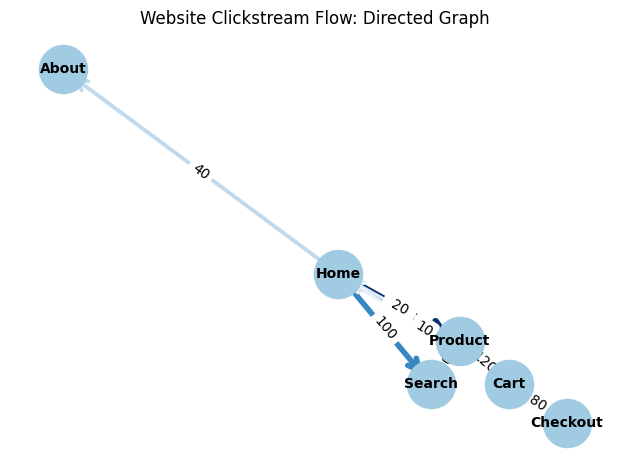

In [9]:
#4. Directed Graph (Flow Style)
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Sample clickstream data
data = pd.DataFrame({
    'source': ['Home', 'Home', 'Product', 'Product', 'Cart', 'Cart', 'Search', 'Home'],
    'target': ['Product', 'Search', 'Cart', 'Home', 'Checkout', 'Home', 'Product', 'About'],
    'weight': [150, 100, 120, 20, 80, 10, 60, 40]
})

# Create a directed graph
G = nx.DiGraph()

# Add weighted edges
for _, row in data.iterrows():
    G.add_edge(row['source'], row['target'], weight=row['weight'])

# Layout: spring for flow effect
pos = nx.spring_layout(G, seed=42, k=1)

# Get weights for edge color mapping
weights = [G[u][v]['weight'] for u, v in G.edges()]
max_weight = max(weights)

# Normalize edge weights to a color scale
edge_colors = [plt.cm.Blues(w / max_weight) for w in weights]

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=1200, node_color="#A0CBE2")

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw directed edges with weight-based color
nx.draw_networkx_edges(
    G,
    pos,
    arrowstyle='->',
    arrowsize=20,
    edge_color=edge_colors,
    width=[2 + w / 50 for w in weights]
)

# Add edge weight labels
edge_labels = {(u, v): f"{d['weight']}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Website Clickstream Flow: Directed Graph")
plt.axis('off')
plt.tight_layout()
plt.show()


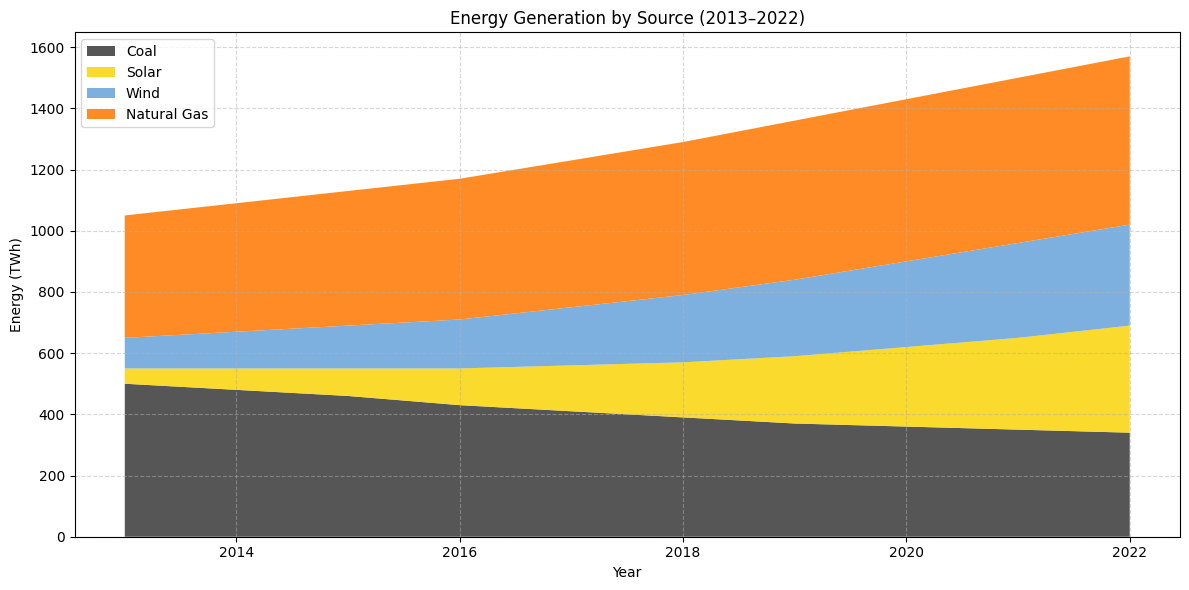

In [13]:
#5. Stream Graph
import matplotlib.pyplot as plt
import pandas as pd

# Simulated energy source data (TWh)
data = pd.DataFrame({
    "Year": list(range(2013, 2023)),
    "Coal": [500, 480, 460, 430, 410, 390, 370, 360, 350, 340],
    "Solar": [50, 70, 90, 120, 150, 180, 220, 260, 300, 350],
    "Wind": [100, 120, 140, 160, 190, 220, 250, 280, 310, 330],
    "Natural Gas": [400, 420, 440, 460, 480, 500, 520, 530, 540, 550]
})

# Set index and prepare stack data
years = data["Year"]
sources = ['Coal', 'Solar', 'Wind', 'Natural Gas']
values = [data[source] for source in sources]

# Plot stack (stream-style) graph
plt.figure(figsize=(12, 6))
colors = ['#444444', '#f9d616', '#6fa8dc', '#ff7f0e']
plt.stackplot(years, values, labels=sources, colors=colors, alpha=0.9)

plt.title("Energy Generation by Source (2013–2022)")
plt.xlabel("Year")
plt.ylabel("Energy (TWh)")
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
